# Tutorial_6_Cloud_Postprocessing

This tutorial overlays the gas, total-cloud, and **individual cloud-component** $\tau=1$ pressure curves on the v2 contribution function. Unlike the Brewster v1 `cloudpost` routine, this uses the current v2 Python output objects, saved cloud-opacity arrays, and Fortran forward model.

The individual curves are calculated by retaining one column of `cloudmap` at a time. Therefore they use the same cloud profiles, particle distributions, opacity interpolation, and optical-depth calculation as the retrieval. A zero pressure means that component does not reach $\tau=1$ inside the model grid.

In [1]:
from collections import namedtuple
import pickle

import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np

import settings
import utils
from cloud_postprocessing import (
    get_cloud_photospheres,
    get_cloud_layer_optical_depth,
    normalized_contribution,
    plot_cloud_layer_optical_depth,
)
%matplotlib inline

## 1. Load a v2 retrieval

Set `path`, `runname`, and `fin` as in Tutorial 4. The three assignments to `settings` are required because the forward model reads these saved opacity arrays from module state.

In [2]:
path = "/Users/fw23aao/spidernail/brewster_trail/v2_master/result/"  # include the trailing slash
runname = "vosimp0136_NH3_N_thetamax_alphaprior"
fin = 0  # 1: finished chain; 0: unfinished chain

flatendchain, flatendprobs, ndim = utils.get_endchain(runname, fin, path)
theta_max_end = flatendchain[np.argmax(flatendprobs)]

runargs = utils.pickle_load(path + runname + "_runargs.pic")
opacities = utils.pickle_load(path + runname + "_opacities.pic")
cloudata = utils.pickle_load(path + runname + "_cloudata.pic")
with open(path + runname + "_configs.pic", "rb") as file:
    configs = pickle.load(file)

re_params = configs["re_params"]
settings.init(runargs)
settings.linelist = opacities[0]
settings.cia = opacities[1]
settings.cloudata = cloudata

Unfinished symphony. Number of successful iterations =  30000
maximum likelihood =  10387.504986484033
maximum likelihood in final 2K iterations=  10387.504986484033


## 2. Calculate the cloud-component photospheres

This performs one full diagnostic call plus one call per cloud component, so it can take several times longer than a normal spectrum call. It does not modify `runargs.cloudmap`. Each `species[:, i, :]` entry corresponds to column `i` of that cloud map.

In [3]:
cloud_diag = get_cloud_photospheres(theta_max_end, re_params, runargs)

print("cloudmap:\n", runargs.cloudmap)
for index, label in enumerate(cloud_diag.labels):
    print(f"column {index}: {label}")
print("species array shape (patch, cloud, wavelength):", cloud_diag.species.shape)

cloudmap:
 [[1 1]
 [1 0]]
column 0: Fe.mieff
column 1: Mg2SiO4.mieff
species array shape (patch, cloud, wavelength): (2, 2, 24981)


## 3. Plot one patch

Only positive photospheric pressures are drawn. A missing segment is physically meaningful: that opacity source has integrated optical depth below one over that wavelength range. Set `patch_index` to inspect another patch in a patchy retrieval.

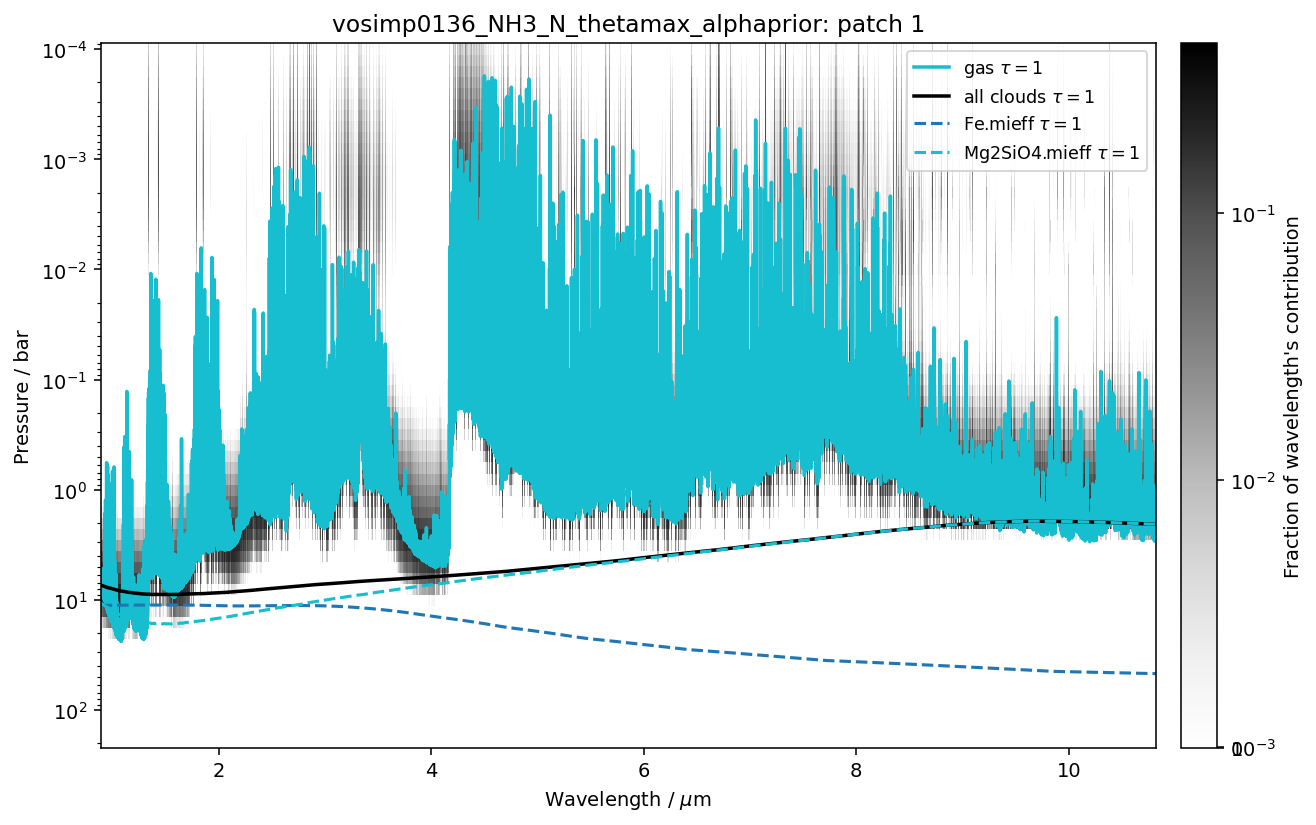

In [4]:
patch_index = 0
wave = cloud_diag.wavelength
pressure = cloud_diag.pressure
norm_cf = normalized_contribution(cloud_diag.contribution[patch_index])

fig, ax = plt.subplots(figsize=(10, 6), dpi=140)
mesh = ax.pcolormesh(
    wave, pressure, norm_cf.T, shading="auto", cmap="Greys",
    norm=colors.SymLogNorm(linthresh=1e-3, linscale=1e-3,
                              vmin=0.0, vmax=max(norm_cf.max(), 1e-3)),
)

def plot_positive(curve, *args, **kwargs):
    visible = np.asarray(curve, dtype=float).copy()
    visible[visible <= 0] = np.nan
    ax.plot(wave, visible, *args, **kwargs)

plot_positive(cloud_diag.gas[patch_index], color="tab:cyan", lw=1.8,
              label=r"gas $\tau=1$")
plot_positive(cloud_diag.total_cloud[patch_index], color="black", lw=1.8,
              label=r"all clouds $\tau=1$")

cloud_colours = plt.cm.tab10(np.linspace(0, 1, cloud_diag.species.shape[1]))
for cloud_index, (label, colour) in enumerate(zip(cloud_diag.labels, cloud_colours)):
    if runargs.cloudmap[patch_index, cloud_index] != 0:
        plot_positive(cloud_diag.species[patch_index, cloud_index],
                      color=colour, lw=1.6, ls="--",
                      label=rf"{label} $\tau=1$")

ax.set_yscale("log")
ax.invert_yaxis()
ax.set_xlabel(r"Wavelength / $\mu$m")
ax.set_ylabel("Pressure / bar")
ax.set_title(f"{runname}: patch {patch_index + 1}")
ax.legend(loc="best", fontsize=9)
cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label("Fraction of wavelength's contribution")
fig.tight_layout()
plt.show()

## 4. Access the arrays directly

The useful fields are `wavelength`, `pressure`, `contribution`, `gas`, `total_cloud`, `species`, and `labels`. For example, the following extracts one component and masks wavelengths where it never becomes optically thick.

In [5]:
cloud_index = 0
tau_one_pressure = cloud_diag.species[patch_index, cloud_index]
optically_thick = tau_one_pressure > 0
component_wave = cloud_diag.wavelength[optically_thick]
component_pressure = tau_one_pressure[optically_thick]

## 5. Layer-by-layer cloud optical thickness

Brewster parameterizes each cloud profile using its layer optical thickness at the 1 $\mu$m reference wavelength. The following calculation does not rerun the forward model and keeps every cloud component separate. Use `cumulative=False` for $\Delta\tau$ in each layer, or `cumulative=True` for optical depth integrated downward from the top of the atmosphere.

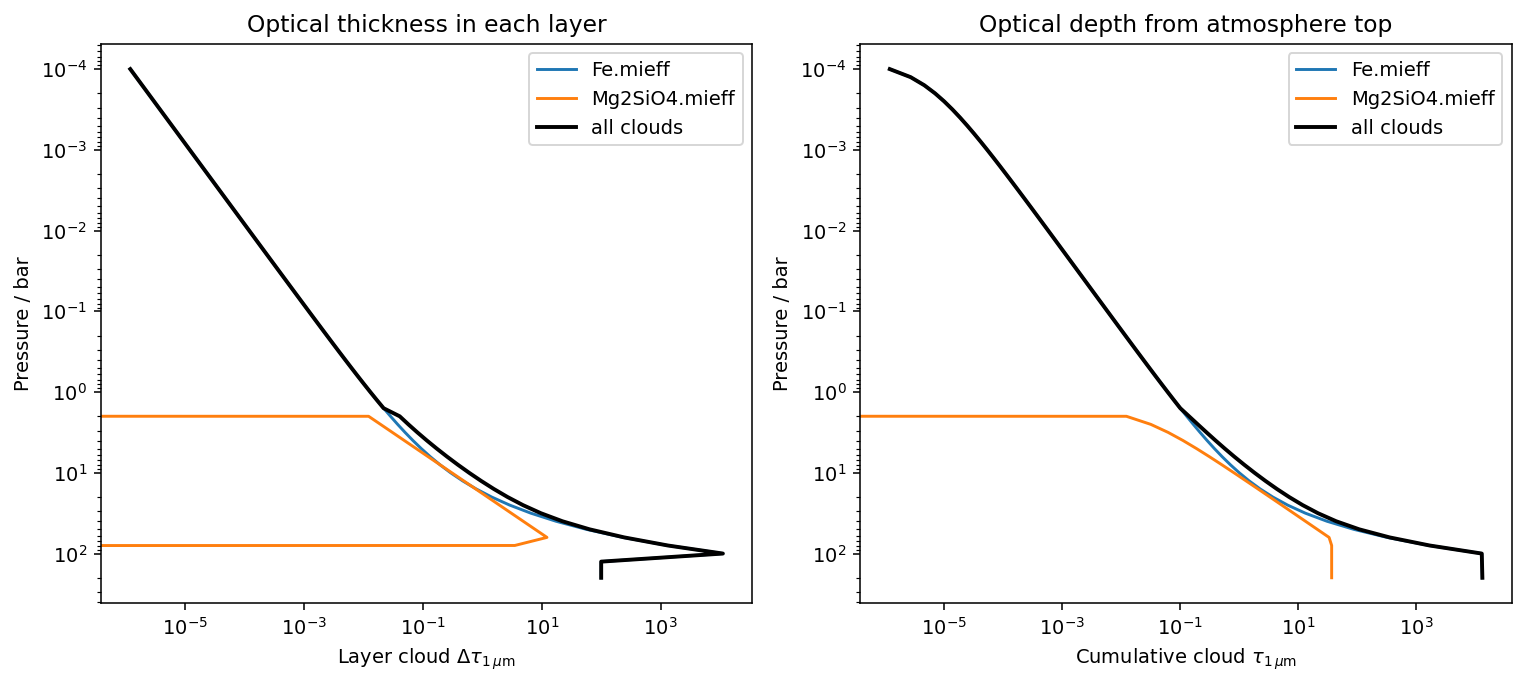

In [6]:
layer_clouds = get_cloud_layer_optical_depth(theta_max_end, re_params, runargs)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), dpi=140)
plot_cloud_layer_optical_depth(layer_clouds, patch=patch_index,
                                   cumulative=False, ax=axes[0])
plot_cloud_layer_optical_depth(layer_clouds, patch=patch_index,
                                   cumulative=True, ax=axes[1])
axes[0].set_title("Optical thickness in each layer")
axes[1].set_title("Optical depth from atmosphere top")
fig.tight_layout()
plt.show()